In [ ]:
# Run this setup only in Google Colab
import os
import subprocess
import sys

try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Colab Notebooks/ml2_trabalhos_2026")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", ".", "--no-deps"])
except ModuleNotFoundError:
    print("Not running in Colab; skipping Drive mount and install steps.")

# Trabalho 1 — Classificação de imagens com o Oxford-IIIT Pet

Neste trabalho, você irá treinar e comparar diferentes modelos para classificação de raças no dataset **Oxford-IIIT Pet**.

**Objetivos.**
- construir um pipeline básico de classificação de imagens;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.

**Entregáveis.**
1. Este notebook preenchido e executado.
2. Os pesos do melhor modelo;
2. Respostas curtas e objetivas nas células de texto.
3. Tabelas e gráficos pedidos ao longo do trabalho.

**Regras gerais.**
- Use **PyTorch**.
- Registre as escolhas principais de hiperparâmetros.
- Quando o enunciado pedir comparação, use evidências dos seus resultados.
- Não apague as células do enunciado.
- Use o conjunto de **teste** apenas na etapa final.



## Parte 0 — Setup e reprodutibilidade

Como treinamos algoritmos que possuem escolhas randômicas, e em máquinas com configurações possivelmente distintas. É importante tentar controlar essas variáveis para garantirmos o máximo de reprodutibilidade dos nossos experimentos.

**Tarefa 0.1**  
Fixe as seeds aleatórias e configure o dispositivo (`cpu` ou `cuda`).

**Tarefa 0.2**  
Imprima as versões de `torch` e `torchvision`, e indique se o notebook está usando CPU ou GPU.

**Tarefa 0.3**  
Crie uma variável `student_run_tag` com uma string curta de sua escolha (por exemplo, suas iniciais e a data).  
Use essa tag ao salvar modelos, figuras e demais artefatos produzidos no notebook.



In [1]:
# TODO: importe as bibliotecas principais
import random
import numpy as np
from pathlib import Path
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torchvision
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
from copy import copy
from tqdm.auto import tqdm

# Sugestão: complete com torch.nn, torch.optim, matplotlib etc.

seed = 81
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "dcp_07_04"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 81
Dispositivo: cpu
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: assignment1_outputs/dcp_07_04


/home/al.daniel.pereira/ml2/ml2_trabalhos_2026/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/al.daniel.pereira/ml2/ml2_trabalhos_2026/env/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Carregar dados e fazer split

Use o dataset **Oxford-IIIT Pet** do `torchvision`.

**Tarefas**
1. Baixe/carregue o dataset.
2. Separe os dados em **treino**, **validação** e **teste**.
3. Explique brevemente qual split você usou.
4. Mostre o número de exemplos em cada parte.

**Observação.**
- Você pode usar o split oficial de treino/teste e separar parte do treino para validação.
- Para a maior parte do trabalho, use inicialmente transformações simples.


In [2]:
# TODO:
# - importar OxfordIIITPet
# - definir transformações iniciais
# - carregar conjuntos
# - criar split treino/validação
# - criar DataLoaders

# Estrutura sugerida:
# from torchvision.datasets import OxfordIIITPet
# from torchvision import transforms
# from torch.utils.data import DataLoader, random_split

image_size = 224
batch_size = 64

# Escreva seu código aqui

transform = transforms.Compose([
    transforms.Resize((image_size,image_size)),
    transforms.ToTensor()])

trainval_dataset = OxfordIIITPet(
    root="./data",
    split = "trainval",
    transform=transform,
    download=True,
)

test_dataset = OxfordIIITPet(
    root="./data",
    split = "test",
    transform=transform,
    download=True,
)

# Divisão entre validação e treino 
train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size

train_dataset, val_dataset = random_split(trainval_dataset, [train_size, val_size])

train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = torch.utils.data.DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Total trainval:", len(trainval_dataset))
print("Treino:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))


Total trainval: 3680
Treino: 2944
Validação: 736
Teste: 3669


### Resposta 1.3

Explique brevemente como você construiu o split de treino, validação e teste.

**Resposta:** Dividi o conjunto trainval em 80% para treino e 20% para validação, mantendo o conjunto test separado como fornecido pelo dataset.


## 2. Visualizar dados e inspecionar balanceamento

Antes de treinar, inspecione o dataset.

**Tarefas**
1. Mostre algumas imagens com seus rótulos.
2. Conte quantos exemplos há por classe no conjunto de treino.
3. Faça um gráfico simples da distribuição por classe.
4. Comente se o conjunto parece balanceado ou não.
5. Aponte ao menos uma dificuldade visual do problema.

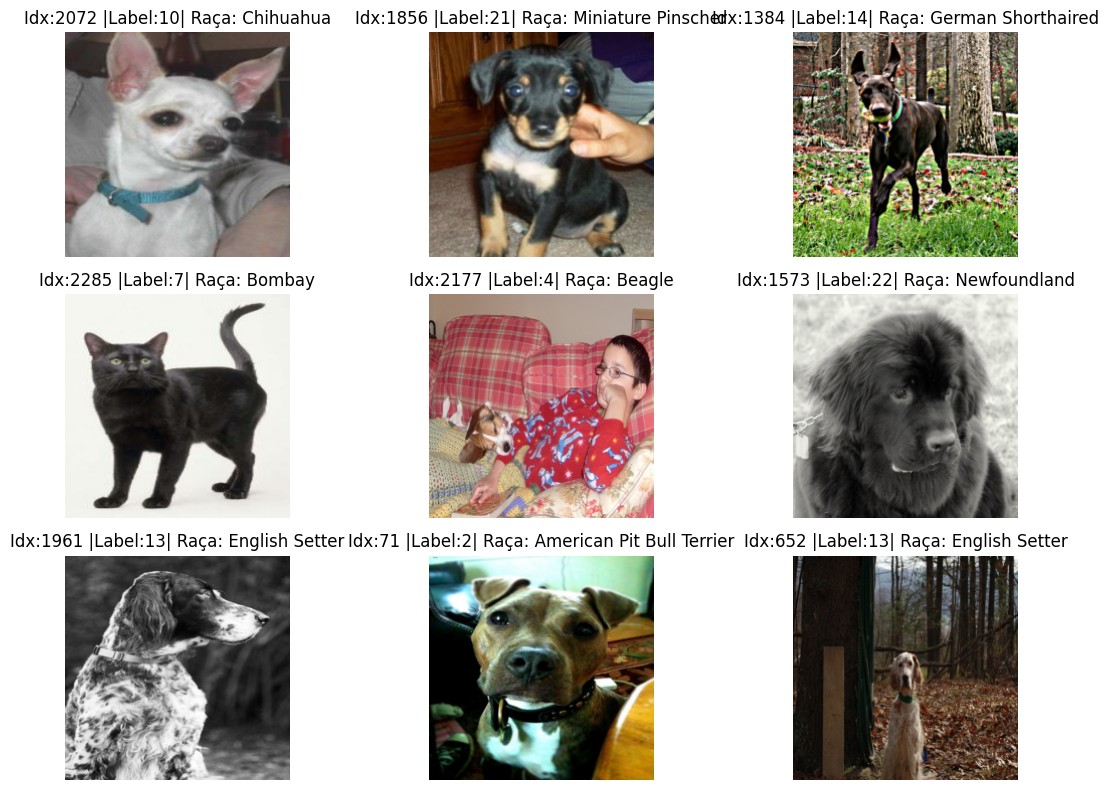

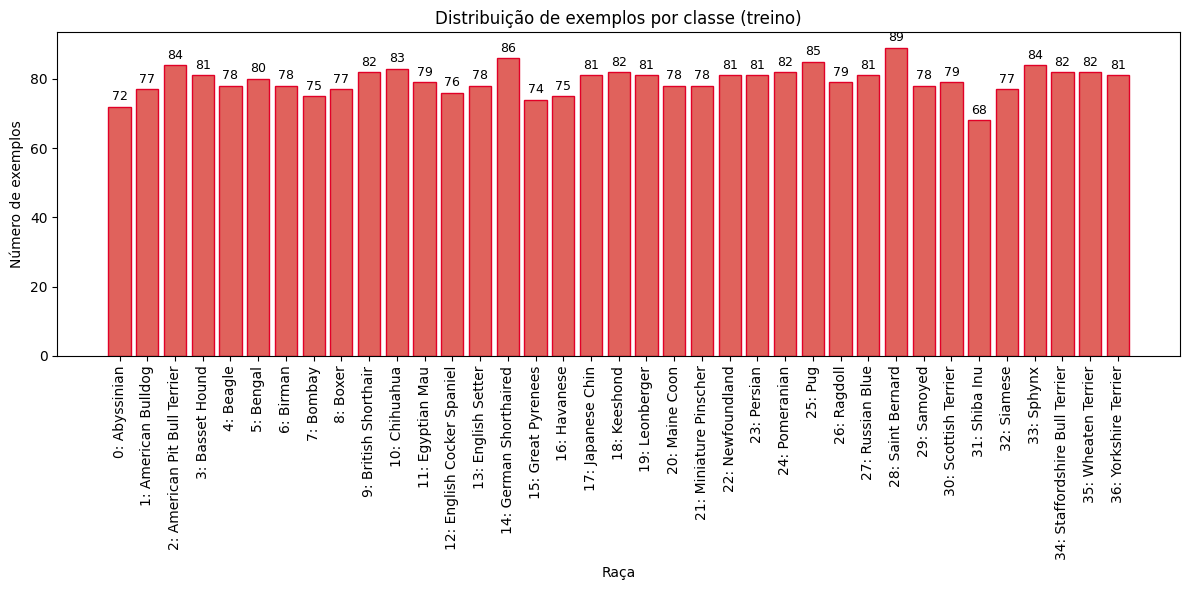

In [3]:
#  acessando nomes das raças
label_to_name = train_dataset.dataset.classes 
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
class_counts = Counter(labels)

classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]
x_labels = [f"{c}: {label_to_name[c]}" for c in classes]

# lista de nome/id
nomes_das_racas = [f"{c}: {label_to_name[c]}" for c in classes]


# indices das amostras
indices = random.sample(range(len(train_dataset)), 9) 

# plot das amostras
plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices):
    image, label = train_dataset[idx]
    image = image.permute(1, 2, 0)
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"Idx:{idx} |Label:{label}| Raça: {label_to_name[label]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

# plot gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(x_labels, counts, color='#E0625C', edgecolor='#E10027')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, yval, ha='center', va='bottom', fontsize=9)
plt.xlabel("Raça")
plt.ylabel("Número de exemplos")
plt.title("Distribuição de exemplos por classe (treino)")
plt.xticks(rotation=90) 
plt.tight_layout()
plt.show()

### Resposta 2.4–2.5

Com base nas visualizações e na distribuição por classe, descreva brevemente o que você observou.

**Resposta:** As classes estão bem uniforme, com pouca variação de quantidade de imagens por classe. Algumas imagens possuem muitos outros elementos o que pode dificultar na identificação da raça. 

## 3. Construa uma FNN simples

Agora construa um primeiro modelo totalmente conectado (**FNN**).

**Tarefas**
1. Defina uma arquitetura simples em PyTorch.
2. Sua FNN deve receber a imagem achatada.
3. Escolha dimensões ocultas razoáveis.
4. Informe o número de parâmetros do modelo.

**Observação.**
Este modelo serve como baseline simples. Não é esperado que funcione bem.


In [4]:
# TODO:
# - definir uma classe FNN(nn.Module)
# - achatar a entrada
# - retornar logits para o número de classes
# - criar uma instância do modelo

# Dica:
# class SimpleFNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleFNN(nn.Module):
    def __init__(self, input_shape=(3, 224, 224), num_classes=37):
        super(SimpleFNN, self).__init__()
        
        # tamanho da entrada achatada
        self.input_dim = input_shape[0] * input_shape[1] * input_shape[2]
        
        # arquitetura
        self.flatten = nn.Flatten()
        
        self.network = nn.Sequential(
            nn.Linear(self.input_dim, 512), 
            nn.ReLU(),
            nn.Linear(512, 256),            
            nn.ReLU(),
            nn.Linear(256, num_classes)     
        )
        
    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits


model = SimpleFNN().to(device)

# informações do modelo
total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo instanciado no dispositivo: {device}")
print(f"Número total de parâmetros: {total_params:,}")

print("\nEstrutura do modelo:")
print(model)


Modelo instanciado no dispositivo: cuda
Número total de parâmetros: 77,211,685

Estrutura do modelo:
SimpleFNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=150528, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=37, bias=True)
  )
)


## 4. Crie funções de treino e avaliação

Implemente funções reutilizáveis para os próximos experimentos.

**Tarefas**
1. Crie uma função `train_one_epoch`.
2. Crie uma função `evaluate`.
3. Crie uma função `fit` que registre métricas por época.
4. Sua avaliação deve retornar pelo menos:
   - loss média
   - acurácia

**Importante.**
Essas funções serão reutilizadas em várias partes do trabalho.


In [5]:
# TODO:
# - implementar train_one_epoch
# - implementar evaluate
# - implementar fit
# - opcional: salvar histórico em dicionário

# Assinaturas sugeridas:
# def train_one_epoch(model, loader, optimizer, criterion, device):
#     ...
#
# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     ...
#
# def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
#     ...

# Escreva seu código aqui


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        # forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # backward pass e otimização
        loss.backward()
        optimizer.step()
        
        # métricas
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="Evaluating", leave=False):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs, scheduler=None):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        if scheduler:
            scheduler.step()
            
        # Registro das métricas
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f"Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4%}")
        print(f"Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4%}")
        print("_" * 40)
        
    return history

## 5. Treine e avalie a FNN

Use as funções anteriores para treinar sua FNN.

**Tarefas**
1. Escolha uma loss apropriada.
2. Escolha um otimizador.
3. Treine por algumas épocas.
4. Mostre curvas de treino/validação.
5. Reporte as métricas finais em validação.
6. Faça um comentário curto sobre o desempenho da FNN.

**Sugestão.**
Registre as escolhas de hiperparâmetros em uma célula ou tabela.


In [6]:
# TODO:
# - definir criterion e optimizer
# - treinar a FNN
# - guardar histórico
# - plotar curvas
# - reportar métricas finais

# Escreva seu código aqui

# definindo as ferramentas
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# Rodando o loop de treino
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=30
)


Epoch [1/30]
Train - Loss: 3.7036 | Acc: 4.0421%
Val   - Loss: 3.5598 | Acc: 5.9783%
________________________________________


Epoch [2/30]
Train - Loss: 3.4838 | Acc: 7.5068%
Val   - Loss: 3.4802 | Acc: 8.2880%
________________________________________


Epoch [3/30]
Train - Loss: 3.4159 | Acc: 8.7296%
Val   - Loss: 3.5140 | Acc: 5.0272%
________________________________________


Epoch [4/30]
Train - Loss: 3.2847 | Acc: 11.1073%
Val   - Loss: 3.4256 | Acc: 7.8804%
________________________________________


Epoch [5/30]
Train - Loss: 3.2430 | Acc: 12.7717%
Val   - Loss: 3.4388 | Acc: 7.7446%
________________________________________


...

Epoch [26/30]
Train - Loss: 2.0503 | Acc: 46.7391%
Val   - Loss: 3.6161 | Acc: 8.6957%
________________________________________


Epoch [27/30]
Train - Loss: 2.0115 | Acc: 47.7921%
Val   - Loss: 3.6315 | Acc: 8.9674%
________________________________________


Epoch [28/30]
Train - Loss: 1.9510 | Acc: 48.8791%
Val   - Loss: 3.6576 | Acc: 8.9674%
________________________________________


Epoch [29/30]
Train - Loss: 1.9622 | Acc: 46.8071%
Val   - Loss: 3.6838 | Acc: 8.6957%
________________________________________


Epoch [30/30]
Train - Loss: 1.8712 | Acc: 50.7133%
Val   - Loss: 3.7030 | Acc: 9.1033%
________________________________________


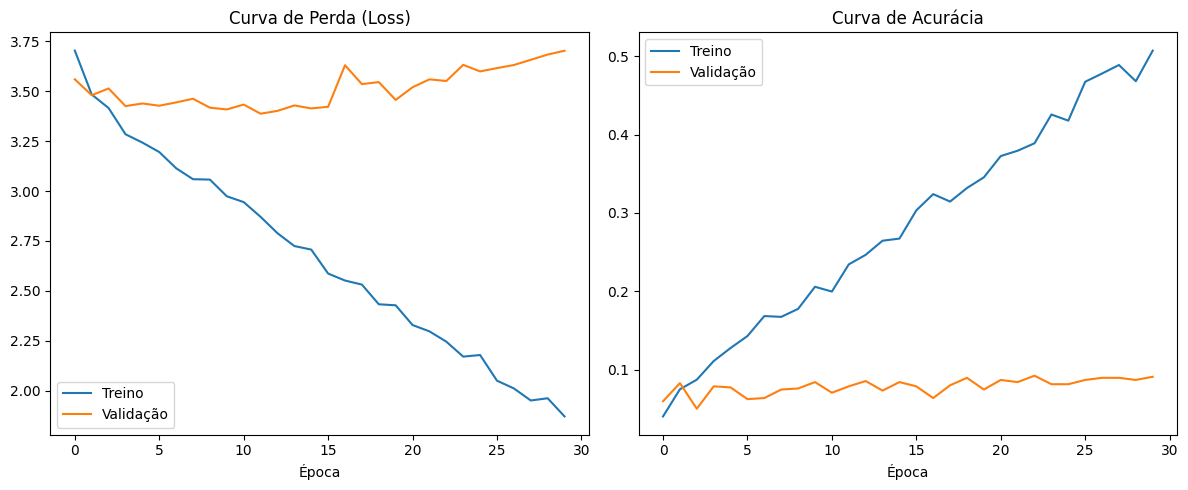

Acurácia Final na Validação: 9.10%


In [7]:
plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Treino')
plt.plot(history['val_loss'], label='Validação')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.legend()

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Treino')
plt.plot(history['val_acc'], label='Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

# Métricas Finais
print(f"Acurácia Final na Validação: {history['val_acc'][-1]:.2%}")

### Resposta 5.6

Comente brevemente o desempenho da FNN. Ela parece adequada para esse problema? Por quê?

**Resposta:** A FNN não funciona para esse caso porque ela transforma a imagem num vetor e perde toda a noção de onde as coisas estão. Ela basicamente tenta decorar a cor de cada pixel em vez de aprender o que é um focinho ou uma orelha, o que gera um overfitting gigante e uma acurácia bem baixa.

## 6. Construa uma CNN simples e compare com a FNN

Agora implemente uma CNN simples.

**Tarefas**
1. Defina uma CNN com algumas camadas convolucionais.
2. Treine e avalie a CNN usando o mesmo protocolo da FNN.
3. Compare FNN e CNN em termos de:
   - acurácia;
   - comportamento das curvas;
   - número de parâmetros.

**Observação.**
A comparação deve ser baseada nos seus resultados.


In [8]:
# TODO:
# - definir uma CNN simples
# - treinar
# - avaliar
# - comparar com a FNN

# Dica:
# class SimpleCNN(nn.Module):
#     ...

# Escreva seu código aqui

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        self.conv = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(8 * 112 * 112, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv(x)))
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x
# Instanciar e contar parâmetros
cnn_model = SimpleCNN().to(device)
cnn_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Número total de parâmetros da CNN: {cnn_params:,}")



Número total de parâmetros da CNN: 3,713,285


#### Treino

In [9]:
optimizer_cnn = torch.optim.Adam(cnn_model.parameters(), lr=0.0001)

history_cnn = fit(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_cnn,
    criterion=criterion,
    device=device,
    epochs=30
)

Epoch [1/30]
Train - Loss: 3.6292 | Acc: 5.0272%
Val   - Loss: 3.5000 | Acc: 6.3859%
________________________________________


Epoch [2/30]
Train - Loss: 3.3015 | Acc: 11.8207%
Val   - Loss: 3.3884 | Acc: 10.0543%
________________________________________


Epoch [3/30]
Train - Loss: 3.0846 | Acc: 18.5802%
Val   - Loss: 3.3389 | Acc: 9.6467%
________________________________________


Epoch [4/30]
Train - Loss: 2.9038 | Acc: 23.7772%
Val   - Loss: 3.2428 | Acc: 10.1902%
________________________________________


Epoch [5/30]
Train - Loss: 2.6967 | Acc: 31.3179%
Val   - Loss: 3.2372 | Acc: 11.6848%
________________________________________


...

Epoch [26/30]
Train - Loss: 0.4400 | Acc: 96.2976%
Val   - Loss: 3.4897 | Acc: 13.4511%
________________________________________


Epoch [27/30]
Train - Loss: 0.4029 | Acc: 97.3166%
Val   - Loss: 3.5406 | Acc: 15.3533%
________________________________________


Epoch [28/30]
Train - Loss: 0.3639 | Acc: 97.8940%
Val   - Loss: 3.5539 | Acc: 13.3152%
________________________________________


Epoch [29/30]
Train - Loss: 0.3443 | Acc: 97.8601%
Val   - Loss: 3.5329 | Acc: 15.3533%
________________________________________


Epoch [30/30]
Train - Loss: 0.3076 | Acc: 98.1318%
Val   - Loss: 3.5900 | Acc: 14.2663%
________________________________________


#### Plot

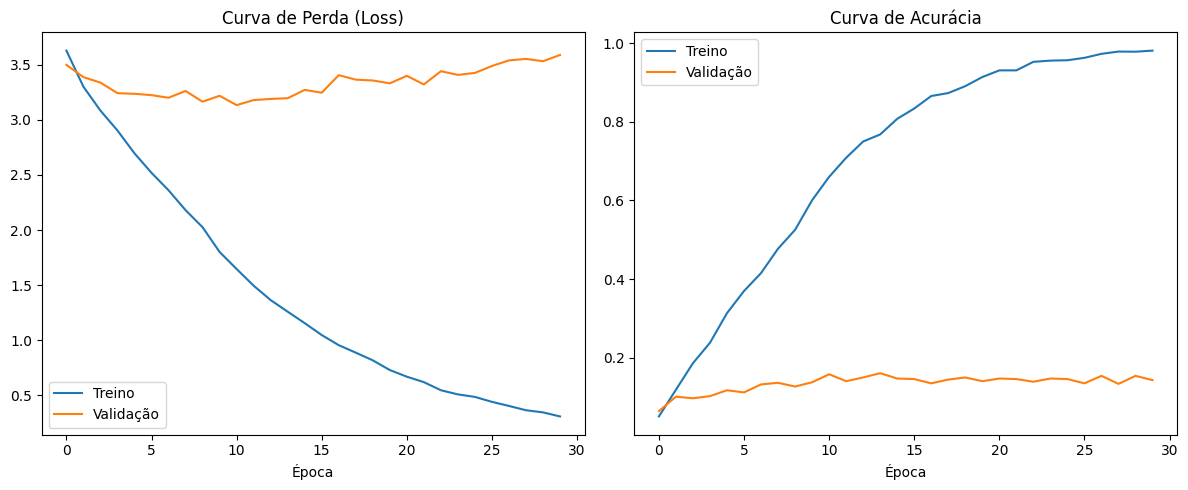

Acurácia Final na Validação: 14.27%


In [10]:
plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn['train_loss'], label='Treino')
plt.plot(history_cnn['val_loss'], label='Validação')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.legend()

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(history_cnn['train_acc'], label='Treino')
plt.plot(history_cnn['val_acc'], label='Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

# Métricas Finais
print(f"Acurácia Final na Validação: {history_cnn['val_acc'][-1]:.2%}")

### Resposta 6.3

Compare FNN e CNN de forma objetiva. O que mudou? O resultado era esperado?

**Resposta:**  A FNN foi ineficiente, mesmo com 77 milhões de parâmetros teve desempenho próximo ao acaso por ignorar a estrutura espacial das fotos. Já a CNN, com "apenas" 3 milhões de parâmetros, obteve resultados superiores, mas sofreu um nítido overfitting.

## 7. Faça pelo menos 3 modificações no treinamento

A partir da sua CNN simples, escolha **pelo menos 3** modificações da lista abaixo:

- Data Augmentation;
- outro otimizador;
- learning rate scheduler;
- batch normalization;
- dropout;
- CNN mais profunda;
- weight decay regularizer.

**Tarefas**
1. Escolha no mínimo 3 modificações.
2. Execute experimentos controlados.
3. Organize os resultados em uma tabela.
4. Indique claramente qual configuração foi a melhor.

**Importante.**
Tente mudar uma coisa por vez sempre que possível.


In [ ]:
# TODO:
# - definir ao menos 3 experimentos
# - treinar cada configuração
# - registrar resultados em uma tabela final

### CNN mais profunda

In [11]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        
        # Bloco 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Bloco 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Bloco 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Bloco 4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # 224 → 112 → 56 → 28 → 14
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.block1(x)  # 32 x 112 x 112
        x = self.block2(x)  # 64 x 56 x 56
        x = self.block3(x)  # 128 x 28 x 28
        x = self.block4(x)  # 256 x 14 x 14
        
        x = torch.flatten(x, 1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Deepcnn_model = DeepCNN().to(device)
cnn_params = sum(p.numel() for p in Deepcnn_model.parameters())
print(f"Número total de parâmetros da CNN: {cnn_params:,}")


Número total de parâmetros da CNN: 26,291,781


#### Treino

In [12]:
optimizer_Deepcnn = torch.optim.Adam(Deepcnn_model.parameters(), lr=0.0001)

history_Deepcnn = fit(
    model=Deepcnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_Deepcnn,
    criterion=criterion,
    device=device,
    epochs=30
)

Epoch [1/30]
Train - Loss: 3.6152 | Acc: 2.7853%
Val   - Loss: 3.6105 | Acc: 2.4457%
________________________________________


Epoch [2/30]
Train - Loss: 3.6116 | Acc: 2.5815%
Val   - Loss: 3.6105 | Acc: 2.4457%
________________________________________


Epoch [3/30]
Train - Loss: 3.6115 | Acc: 2.8193%
Val   - Loss: 3.6120 | Acc: 1.4946%
________________________________________


Epoch [4/30]
Train - Loss: 3.5931 | Acc: 3.2609%
Val   - Loss: 3.5065 | Acc: 5.7065%
________________________________________


Epoch [5/30]
Train - Loss: 3.4103 | Acc: 7.8465%
Val   - Loss: 3.3815 | Acc: 7.8804%
________________________________________


...

Epoch [26/30]
Train - Loss: 0.0001 | Acc: 100.0000%
Val   - Loss: 17.3763 | Acc: 11.6848%
________________________________________


Epoch [27/30]
Train - Loss: 0.0001 | Acc: 100.0000%
Val   - Loss: 17.5581 | Acc: 11.5489%
________________________________________


Epoch [28/30]
Train - Loss: 0.0001 | Acc: 100.0000%
Val   - Loss: 17.7835 | Acc: 11.9565%
________________________________________


Epoch [29/30]
Train - Loss: 0.0000 | Acc: 100.0000%
Val   - Loss: 17.9217 | Acc: 12.0924%
________________________________________


Epoch [30/30]
Train - Loss: 0.0000 | Acc: 100.0000%
Val   - Loss: 18.1135 | Acc: 12.3641%
________________________________________


Overffitou muito rápido, vamos tentar Data Augmentation para ter mais dados para treinar e também para ficar mais difícil do modelo decorar só as posições dos pixels de cada imagem.

### Data Augmentation

In [13]:
# transformações com Augmentation (para o TREINO)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),      # inverte a imagem horizontalmente
    transforms.RandomRotation(degrees=15),       # gira levemente a imagem
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # pequenos deslocamentos
    transforms.ColorJitter(brightness=0.2, contrast=0.2),    # altera brilho e contraste
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# transformações Padrão (para VALIDAÇÃO e TESTE)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_data_full = OxfordIIITPet(root="./data", split="trainval", transform=train_transform, download=True)
val_data_full = OxfordIIITPet(root="./data", split="trainval", transform=val_transform, download=True)

indices = torch.randperm(len(train_data_full)).tolist()
train_size = int(0.8 * len(train_data_full))

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = torch.utils.data.Subset(train_data_full, train_indices)
val_dataset = torch.utils.data.Subset(val_data_full, val_indices)

test_dataset = OxfordIIITPet(root="./data", split="test", transform=val_transform, download=True)

train_loader_aug = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader_aug = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [17]:
Deepcnn_model = DeepCNN().to(device)
optimizer_cnn = torch.optim.Adam(Deepcnn_model.parameters(), lr=0.0001)

history_cnn_4 = fit(
    model=Deepcnn_model,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    optimizer=optimizer_cnn,
    criterion=criterion,
    device=device,
    epochs=30
)

Epoch [1/30]
Train - Loss: 3.6130 | Acc: 2.3098%
Val   - Loss: 3.6112 | Acc: 2.1739%
________________________________________


Epoch [2/30]
Train - Loss: 3.5970 | Acc: 3.2269%
Val   - Loss: 3.5481 | Acc: 5.4348%
________________________________________


Epoch [3/30]
Train - Loss: 3.4746 | Acc: 7.4389%
Val   - Loss: 3.3856 | Acc: 8.2880%
________________________________________


Epoch [4/30]
Train - Loss: 3.4163 | Acc: 7.6766%
Val   - Loss: 3.3404 | Acc: 9.7826%
________________________________________


Epoch [5/30]
Train - Loss: 3.3483 | Acc: 9.4090%
Val   - Loss: 3.3464 | Acc: 8.6957%
________________________________________


...

Epoch [26/30]
Train - Loss: 2.2610 | Acc: 36.2772%
Val   - Loss: 2.9721 | Acc: 18.8859%
________________________________________


Epoch [27/30]
Train - Loss: 2.1992 | Acc: 38.6889%
Val   - Loss: 3.0315 | Acc: 19.8370%
________________________________________


Epoch [28/30]
Train - Loss: 2.1060 | Acc: 38.7228%
Val   - Loss: 2.9911 | Acc: 20.9239%
________________________________________


Epoch [29/30]
Train - Loss: 2.0625 | Acc: 41.7459%
Val   - Loss: 3.1281 | Acc: 22.1467%
________________________________________


Epoch [30/30]
Train - Loss: 2.0238 | Acc: 42.4592%
Val   - Loss: 3.0106 | Acc: 21.3315%
________________________________________


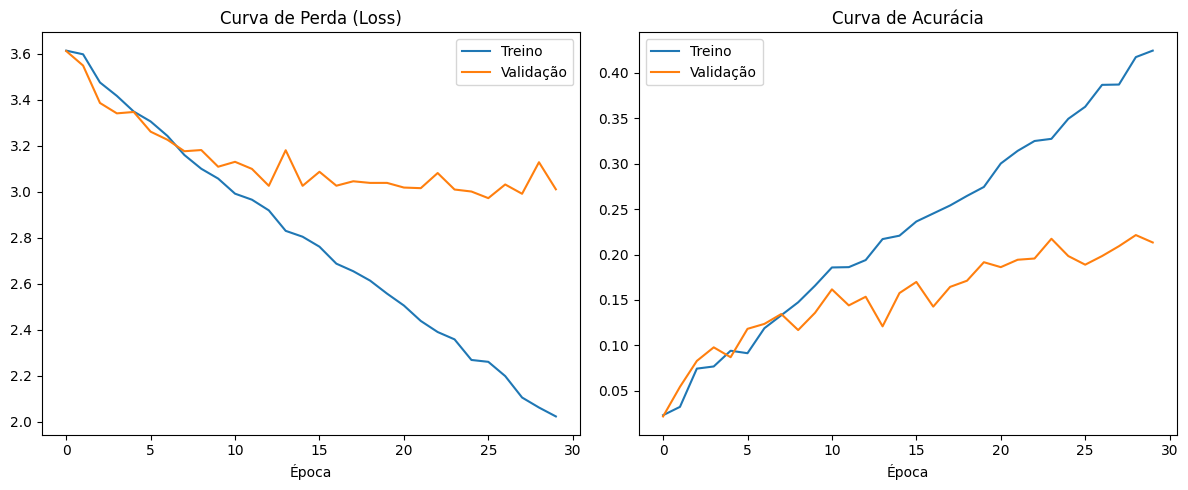

Acurácia Final na Validação: 14.27%


In [18]:
plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn_4['train_loss'], label='Treino')
plt.plot(history_cnn_4['val_loss'], label='Validação')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.legend()

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(history_cnn_4['train_acc'], label='Treino')
plt.plot(history_cnn_4['val_acc'], label='Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

# Métricas Finais
print(f"Acurácia Final na Validação: {history_cnn['val_acc'][-1]:.2%}")

Consigamos um aumento esprexivo na acurácia final de validação de 12% para 21%.

### Batch Normalization

In [19]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=37):
        super().__init__()
        
        # Bloco 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        # Bloco 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        # Bloco 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        # Bloco 4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            
            nn.MaxPool2d(2)
        )
        
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        
        x = torch.flatten(x, 1)
        x = torch.nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
Deepcnn_model = DeepCNN().to(device)
optimizer_cnn = torch.optim.Adam(Deepcnn_model.parameters(), lr=0.0001)

history_cnn_5 = fit(
    model=Deepcnn_model,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    optimizer=optimizer_cnn,
    criterion=criterion,
    device=device,
    epochs=100
)

Epoch [1/100]
Train - Loss: 3.7866 | Acc: 4.8234%
Val   - Loss: 3.4759 | Acc: 8.8315%
________________________________________


Epoch [2/100]
Train - Loss: 3.3826 | Acc: 10.2921%
Val   - Loss: 3.2737 | Acc: 14.1304%
________________________________________


Epoch [3/100]
Train - Loss: 3.1997 | Acc: 13.1454%
Val   - Loss: 3.0874 | Acc: 17.3913%
________________________________________


Epoch [4/100]
Train - Loss: 3.0439 | Acc: 17.0856%
Val   - Loss: 2.9518 | Acc: 21.1957%
________________________________________


Epoch [5/100]
Train - Loss: 2.9276 | Acc: 19.3274%
Val   - Loss: 2.8616 | Acc: 22.0109%
________________________________________


...

Epoch [14/100]
Train - Loss: 2.2356 | Acc: 37.2283%
Val   - Loss: 2.5048 | Acc: 28.6685%
________________________________________


Epoch [15/100]
Train - Loss: 2.1651 | Acc: 38.3832%
Val   - Loss: 2.4695 | Acc: 28.5326%
________________________________________


Epoch [16/100]
Train - Loss: 2.1154 | Acc: 39.1644%
Val   - Loss: 2.4625 | Acc: 30.5707%
________________________________________


Epoch [17/100]
Train - Loss: 2.0162 | Acc: 42.1535%
Val   - Loss: 2.5932 | Acc: 28.9402%
________________________________________


Training:  65%|██████▌   | 30/46 [00:10<00:05,  2.89it/s]

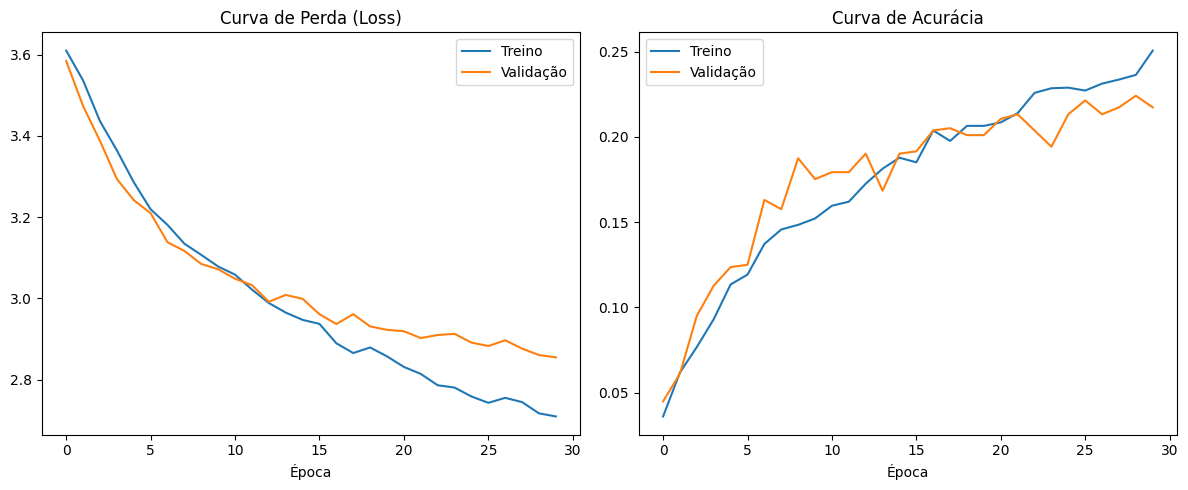

Acurácia Final na Validação: 21.74%


In [ ]:
plt.figure(figsize=(12, 5))

# Gráfico de Loss
plt.subplot(1, 2, 1)
plt.plot(history_cnn_5['train_loss'], label='Treino')
plt.plot(history_cnn_5['val_loss'], label='Validação')
plt.title('Curva de Perda (Loss)')
plt.xlabel('Época')
plt.legend()

# Gráfico de Acurácia
plt.subplot(1, 2, 2)
plt.plot(history_cnn_5['train_acc'], label='Treino')
plt.plot(history_cnn_5['val_acc'], label='Validação')
plt.title('Curva de Acurácia')
plt.xlabel('Época')
plt.legend()

plt.tight_layout()
plt.show()

# Métricas Finais
print(f"Acurácia Final na Validação: {history_cnn_5['val_acc'][-1]:.2%}")

### Resposta 7.4

Liste as modificações escolhidas e justifique em 1–2 linhas por que você decidiu testá-las.


## 8. Analise e discuta o efeito das mudanças

Com base nos experimentos da parte anterior:

**Tarefas**
1. Discuta quais mudanças ajudaram mais.
2. Discuta quais mudanças pouco ajudaram ou pioraram o resultado.
3. Comente possíveis razões para o comportamento observado.
4. Indique qual modelo/configuração você levará para a etapa final.

Use evidências das métricas e curvas.


### Resposta 8

Escreva sua análise aqui.


## 9. Treine usando uma ResNet pré-treinada

Agora use **transfer learning** com uma **ResNet pré-treinada**.

**Tarefas**
1. Carregue uma ResNet pré-treinada do `torchvision`.
2. Adapte a última camada para o número de classes.
3. Treine ao menos uma versão usando transfer learning.
4. Compare com sua melhor CNN da Parte 7.

**Sugestão.**
Você pode começar congelando a maior parte da rede e depois testar fine-tuning.


In [ ]:
# TODO:
# - carregar uma ResNet pré-treinada
# - adaptar a camada final
# - treinar
# - avaliar e comparar

# Dica:
# from torchvision.models import resnet18, ResNet18_Weights

# Escreva seu código aqui


### Resposta 9.4

Compare a ResNet com sua melhor CNN anterior. O ganho compensou?


## 10. Avaliações finais

Escolha seu melhor modelo final e faça uma avaliação mais detalhada.

**Tarefas**
1. Avalie no conjunto de teste.
2. Reporte:
   - loss;
   - acurácia;
   - matriz de confusão.
3. Mostre algumas imagens classificadas incorretamente.
4. Identifique pares de classes que geram mais confusão.
5. Discuta brevemente os principais erros do modelo.

**Observação.**
Use esta parte para mostrar que você inspecionou o comportamento do modelo além da acurácia final.


In [ ]:
# TODO:
# - avaliar no teste
# - calcular matriz de confusão
# - mostrar erros
# - discutir pares confusos

# Sugestão:
# use sklearn.metrics.confusion_matrix ou implementação própria

# Escreva seu código aqui


### Resposta 10.5

Discuta os erros mais importantes observados na avaliação final.


## 11. Bônus — Robustez

Faça um teste simples de robustez com o seu melhor modelo.

**Exemplos de variações possíveis**
- reduzir a resolução da imagem;
- adicionar ruído leve;
- mudar brilho/contraste;
- aplicar blur leve;
- testar imagens com crop diferente.

**Tarefas**
1. Escolha uma perturbação simples.
2. Compare o desempenho antes e depois.
3. Mostre alguns exemplos.
4. Comente o que isso sugere sobre a robustez do modelo.


In [ ]:
# TODO:
# - definir uma perturbação simples
# - reavaliar o melhor modelo
# - comparar métricas
# - mostrar exemplos

# Escreva seu código aqui

## Critérios de avaliação

A correção levará em conta:
- **implementação correta** dos componentes pedidos;
- **qualidade experimental** das comparações;
- **clareza da análise** dos resultados;
- **organização** do notebook;
- **coerência** entre conclusões e evidências.
